# Analítica Avanzada de Datos
-------------------------------------

## Práctica 2. Predicción de Gastos Médicos
#### Nombres: ...
**Objetivo:** Predecir el costo del seguro médico (charges) basado en el Índice de Masa Corporal (bmi), filtrando valores atípicos y preparando el dataset.
El dataset que utilizarán es **"US Health Insurance Dataset"**  https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset

### Parte 1.
#### Deben de realizar:
##### **1. Carga y exploración inicial**
##### **2. Limpieza del dataset**
    * Verificación de nulos
    * Outliers
    * Análisis exploratorio de datos (EDA)

In [68]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error

data_raw = pd.read_csv('./insurance.csv')
data_raw

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [30]:
data_raw.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
data_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Para poder realizar un analsis del dataset se busca identidicar el significado de las variables:
- age (edad)
    Representa la edad del cliente, es un dato de tipo entero.
- sex (sexo)
    Representa el sexo del cliente, es un dato de tipo cadena.
- bmi (imc/indice de masa coportal)
    Representa el indice de masa corporal del cliente, es un dato de tipo flotante.
- childen (hijos)
    Representa el numero de hijos del cliente, es un dato de tipo entero.
- smoker (fumador)
    Representa si el cliente es fumador o no, es un dato de tipo cadena(si o no).
- region
    Representa la parte especifica de residencia del cliente en Estados Unidos(norte, sur, este u oeste), es un dato de tipo cadena.
- charges (cargos)
    Representa los cargos medicos facturados del seguro del cliente, es un dato de tipo flotante.


Este dataset es utlizado con el proposito de carculo de costo para seguros, las variables presentan factores de interes para las aseguradoras al momento de determinvar la viabilidad y rentabilidad de un cliente segun las caracteristicas que posee.

##### **Limpieza del data set**

In [32]:
# Verificar la existencia de valores nulos
data_raw.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

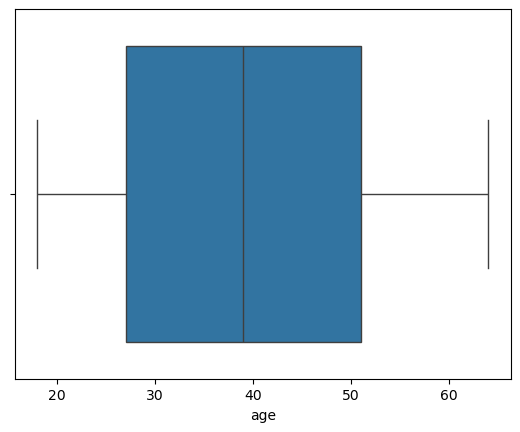

In [33]:
# Presencia de valores atipicos
sns.boxplot(x=data_raw['age'])
plt.show()

El boxplot de age muestra una distribución relativamente simétrica, con una mediana cercana a los 40 años situada al centro de la caja. Los bigotes abarcan aproximadamente desde los 18 hasta los 64 años y no se observan puntos fuera de ellos, lo cual indica ausencia de valores atípicos según la regla de 1.5·IQR. Esto sugiere que la variable edad está bien distribuida y no requiere tratamiento adicional por outliers.

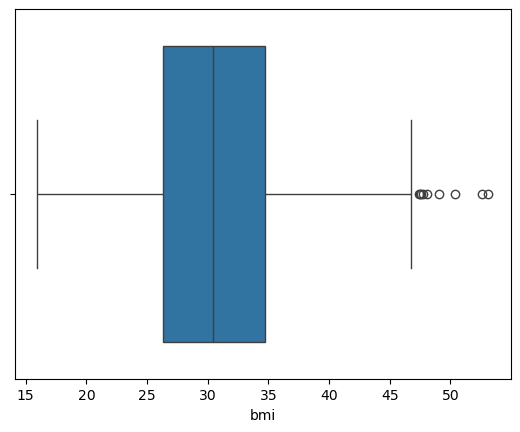

In [34]:
sns.boxplot(x=data_raw['bmi'])
plt.show()

El boxplot de bmi muestra una mediana cercana a 30 y un IQR ubicado aproximadamente entre 26 y 34. Aunque la mayor parte de los valores se concentra en ese rango, aparecen varios puntos por encima del bigote superior, correspondientes a valores atípicos altos (IMC elevado). Esto refleja una cola derecha en la distribución, indicando que existen personas con IMC significativamente mayor al promedio, lo cual debe considerarse para el análisis al aplicar técnicas como filtrado por IQR o revisión de su impacto en el modelo de regresión.

In [35]:
Q1 = data_raw["bmi"].quantile(0.25)
Q3 = data_raw["bmi"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_bmi = data_raw[(data_raw["bmi"] < limite_inferior) | (data_raw["bmi"] > limite_superior)]

In [36]:
outliers_bmi.sort_values(by="bmi", ascending=False)

,age,sex,bmi,children,smoker,region,charges
1317,18,male,53.13,0,no,southeast,1163.46270
1047,22,male,52.58,1,yes,southeast,44501.39820
847,23,male,50.38,1,no,southeast,2438.05520
116,58,male,49.06,0,no,southeast,11381.32540
286,46,female,48.07,2,no,northeast,9432.92530
1088,52,male,47.74,1,no,southeast,9748.91060
860,37,female,47.60,2,yes,southwest,46113.51100
401,47,male,47.52,1,no,southeast,8083.91980
543,54,female,47.41,0,yes,southeast,63770.42801


Los valores atipicos encontrados no representan errores en la captura de los datos, en su lugar son casos extremos del indice de masa coorporal de los clientes, por lo que en este caso se decide preservarlos.

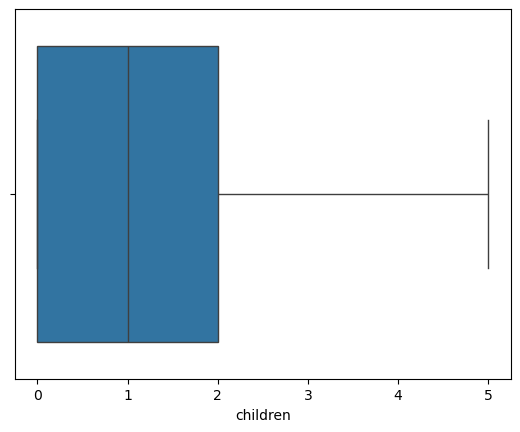

In [37]:
sns.boxplot(x=data_raw['children'])
plt.show()

En el boxplot de children se aprecia que la mayoría de los valores se concentran entre 0 y 2 hijos, con una mediana cercana a 1. Los bigotes se extienden hasta 5 hijos y no aparecen puntos fuera de estos límites, por lo que no se detectan outliers. La distribución es esperada para una variable discreta y no presenta valores extremos que necesiten corrección o filtrado.

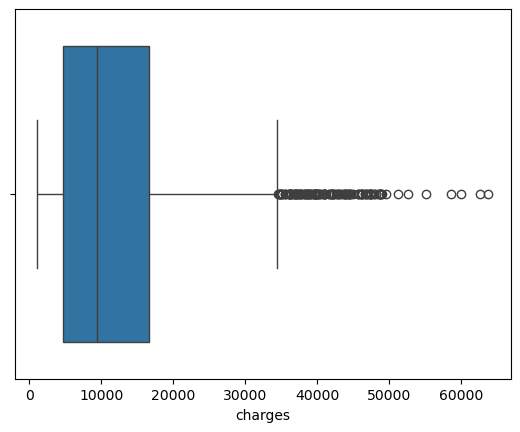

In [38]:
sns.boxplot(x=data_raw['charges'])
plt.show()

El boxplot de charges evidencia una distribución fuertemente asimétrica hacia la derecha, con una mediana alrededor de 10 000 y un IQR entre aproximadamente 7 000 y 16 000. A partir del bigote superior (~35 000) se observa una gran cantidad de puntos dispersos, lo cual indica la presencia de muchos outliers de alto costo. Estos valores extremos representan casos de gastos médicos muy elevados y pueden influir de manera considerable en la regresión lineal, por lo que es recomendable aplicar filtrado o considerar transformaciones como el logaritmo.

In [39]:
Q1 = data_raw["charges"].quantile(0.25)
Q3 = data_raw["charges"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers_charges = data_raw[(data_raw["charges"] < limite_inferior) | (data_raw["charges"] > limite_superior)]

In [40]:
outliers_charges.sort_values(by="charges", ascending=False)

,age,sex,bmi,children,smoker,region,charges
543,54,female,47.410,0,yes,southeast,63770.42801
1300,45,male,30.360,0,yes,southeast,62592.87309
1230,52,male,34.485,3,yes,northwest,60021.39897
577,31,female,38.095,1,yes,northeast,58571.07448
819,33,female,35.530,0,yes,northwest,55135.40209
...,...,...,...,...,...,...,...
1291,19,male,34.900,0,yes,southwest,34828.65400
689,27,male,31.130,1,yes,southeast,34806.46770
223,19,male,34.800,0,yes,southwest,34779.61500
1078,28,male,31.680,0,yes,southeast,34672.14720


Por el volumen de los datos y que si presentan valores de costos para la aseguradora, se opta por el metodo de Winsorizing, en lugar de simplemente eliminarlos, ya que presentan el 10% de los datos.

In [41]:
from scipy.stats.mstats import winsorize

data_raw['charges_winsorized'] = data_raw['charges'].clip(lower=limite_inferior, upper=limite_superior)

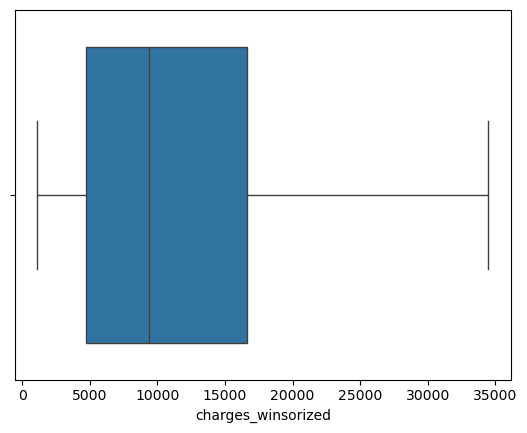

In [42]:
sns.boxplot(x=data_raw['charges_winsorized'])
plt.show()

In [43]:
data_clean = data_raw.copy()

data_clean.drop(columns=['charges'], inplace=True)

In [44]:
data_clean.rename(columns={'charges_winsorized': 'charges'}, inplace=True)

In [45]:
data_clean

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


##### **Observar las distribuciones de las clases**

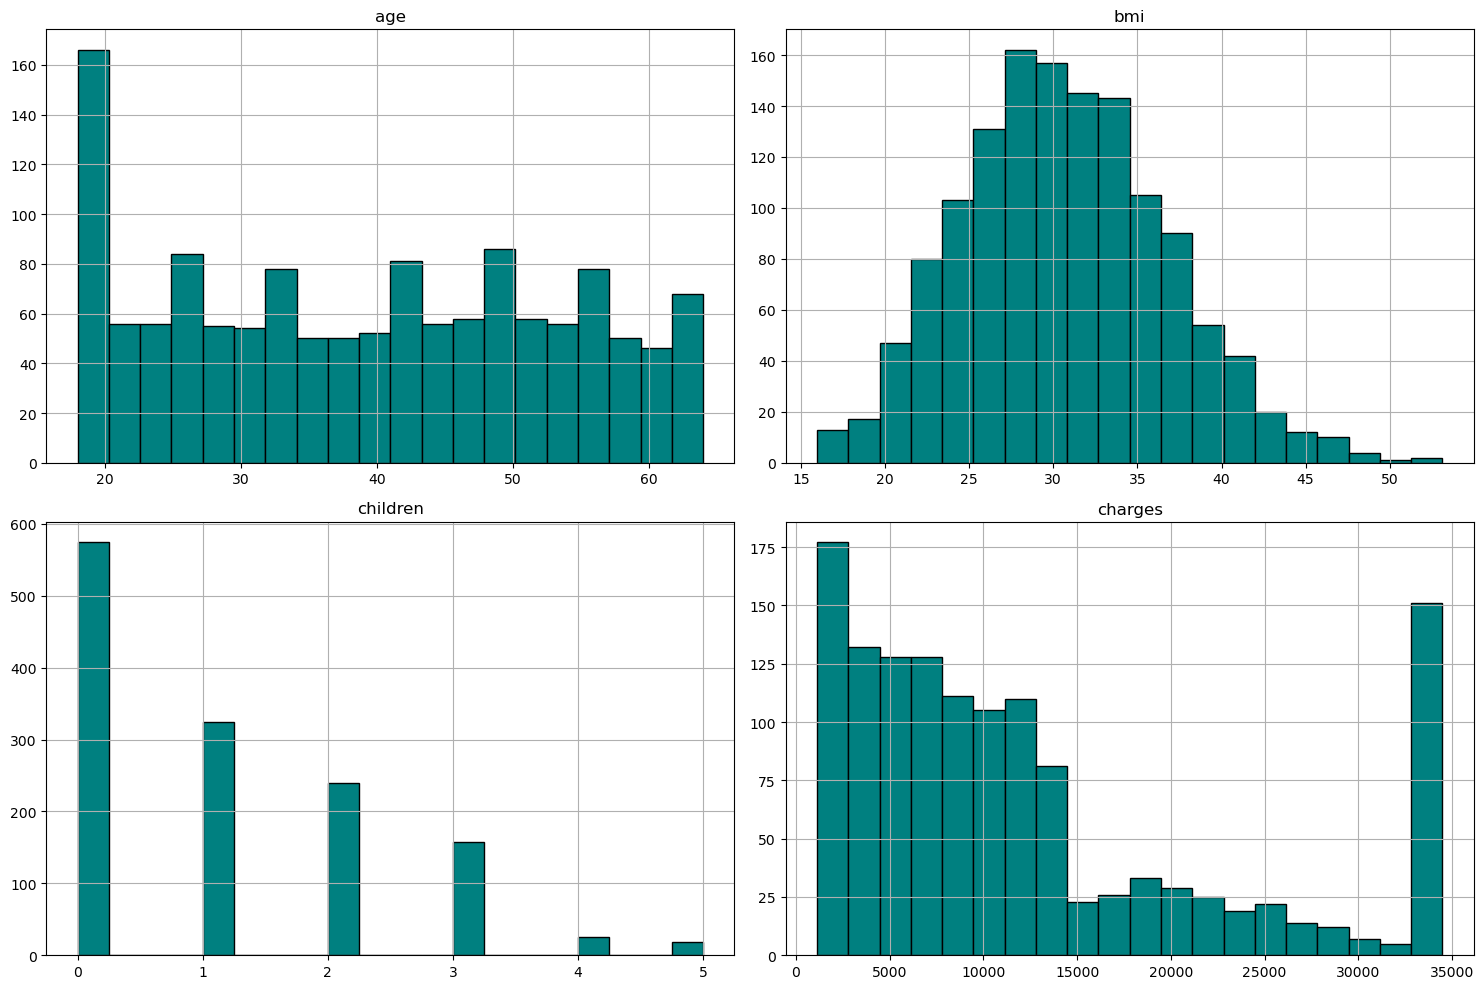

In [46]:
data_clean.hist(bins=20, figsize=(15, 10), color='teal', edgecolor='black')
plt.tight_layout()
plt.show()

Histograma de age
El histograma de age muestra una distribución bastante uniforme entre los 18 y 64 años. Esto indica que la edad de los asegurados está repartida de manera equilibrada a lo largo del rango, sin comportamientos extraños o concentraciones anormales.

Histograma de children
El histograma de children muestra que la mayoría de las personas tienen 0, 1 o 2 hijos, mientras que los valores de 3, 4 y 5 aparecen con mucha menor frecuencia. La distribución está claramente cargada hacia los valores bajos, lo cual es normal para una variable discreta de este tipo y no presenta irregularidades.

Histograma de bmi
El histograma de bmi tiene una forma parecida a una campana, con mayor concentración alrededor de valores cercanos a 30. La distribución es mayormente simétrica, aunque con una ligera tendencia hacia valores más altos, lo cual coincide con la presencia de algunos IMC elevados.

Histograma de charges
El histograma de charges presenta un sesgo hacia la derecha: hay muchas personas con costos más bajos y cada vez menos conforme aumentan los gastos médicos. También se observa una mayor concentración en el límite superior, lo cual se debe a que los valores muy altos fueron ajustados para evitar extremos. Aun así, la forma general indica que los costos siguen siendo muy variables y tienden a acumularse en rangos bajos.


##### **3. Visualización**
##### **4. Modelado (Regresión Lineal)**
##### **5. Evaluación del modelo ($R^2$,MSE,Coeficientes)**

##### **Visualización**

Después de realizar la limpieza del dataset y antes de entrar de lleno con el modelo, es necesario visualizar los datos, por ello, a continuación se presenta los siguientes gráficos de dispersión en 3d rotados de las variables age, bmi y la objetivo charges.

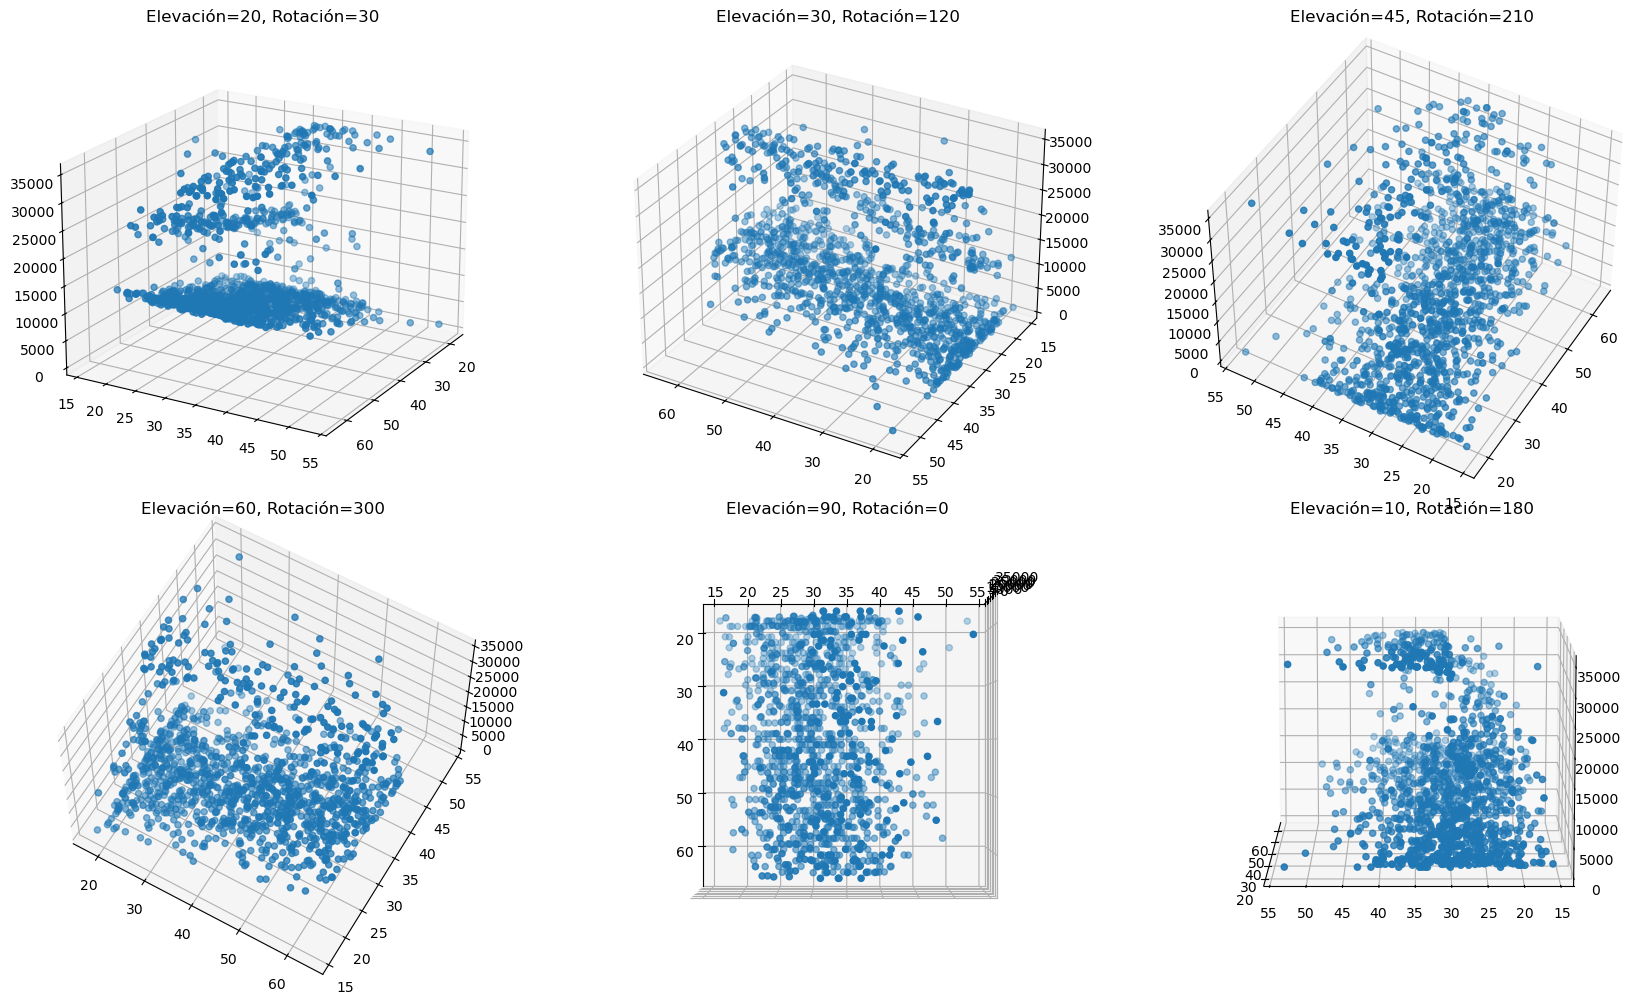

In [47]:
data_clean.loc[:, ['age', 'bmi', 'charges']]

xs = data_clean['age']
ys = data_clean['bmi']
zs = data_clean ['charges']


fig = plt.figure(figsize=(18,10))

angulos = [
    (20, 30),
    (30, 120),
    (45, 210),
    (60, 300),
    (90, 0),
    (10, 180)
]

for i, (elev, azim) in enumerate(angulos):
    ax = fig.add_subplot(2, 3, i+1, projection='3d')
    ax.scatter(xs, ys, zs)
    ax.view_init(elev=elev, azim=azim)
    ax.set_title(f"Elevación={elev}, Rotación={azim}")

plt.tight_layout()
plt.show()

Se puede observar que mientras más grande es la edad y el bmi el costo del seguro médico crece. Sin embargo de momento no podemos aplicar el modelo, falta analizar otra variable númerica, la cual es el número de hijos, es por ello que se presenta el siguiente gráfico de dispersión en 2d incluyendo las varibales age, bmi, children y charges

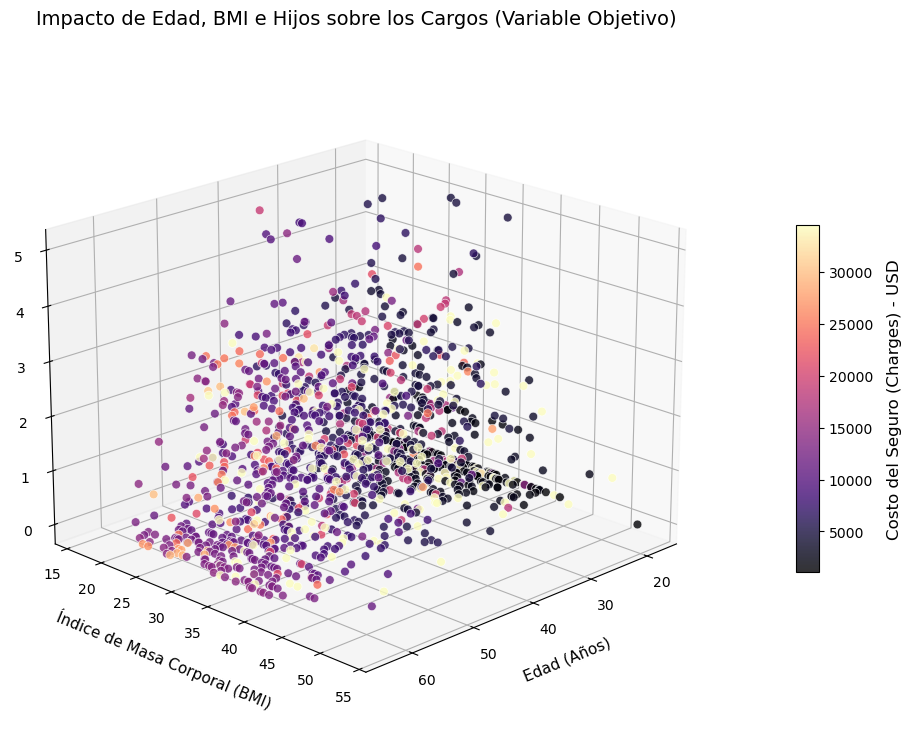

In [48]:
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

x = data_clean['age']
y = data_clean['bmi']
z = data_clean['children']
c = data_clean['charges']

scatter = ax.scatter(
    x, y, z, 
    c=c, 
    cmap='magma', 
    s=40,          # Tamaño de los puntos
    alpha=0.8,     # Transparencia
    edgecolors='w',# Borde blanco
    linewidth=0.5
)
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=15, pad=0.1)
cbar.set_label('Costo del Seguro (Charges) - USD', fontsize=12, labelpad=10)
ax.set_xlabel('Edad (Años)', fontsize=11, labelpad=10)
ax.set_ylabel('Índice de Masa Corporal (BMI)', fontsize=11, labelpad=10)
ax.set_zlabel('Número de Hijos', fontsize=11, labelpad=10)
plt.title('Impacto de Edad, BMI e Hijos sobre los Cargos (Variable Objetivo)', fontsize=14, pad=20)
ax.view_init(elev=20, azim=45) 
# Mostrar la gráfica
plt.show()

Como se puede observar, no se ve simpleme vista la tendencia de los datos en más dimensiones. De forma algo apresurada se puede ver que el costo del seguro es más bajo conforme age, bmi y children bajas. Pero para ver de manera númerica como es que estos datos se relacionan podemos hacer una matriz de correlación de pearson.

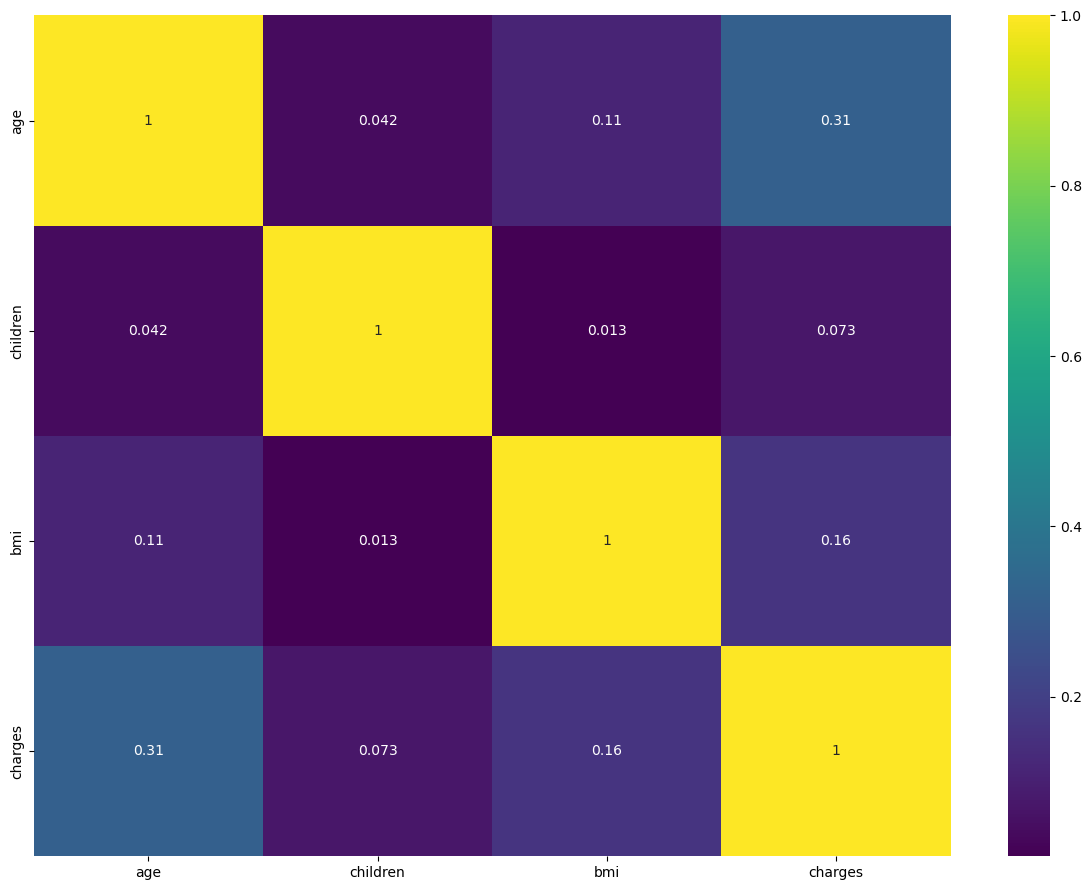

In [49]:
corr1 = data_clean.loc[:, ['age', 'children', 'bmi', 'charges']].corr()


fig = plt.figure(figsize=(12, 9))

# Pearson
sns.heatmap(corr1,cmap='viridis', annot = True)


plt.tight_layout()
plt.show()

Se puede observar que la relación lineal entre nuestra variable objetivo y las númericas no es del todo alta.

##### **Modelado**

In [50]:
X = data_clean.loc[:, ['bmi']]
y = data_clean['charges']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Modelado
model = LinearRegression()

model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


##### **Evaluación**

In [51]:

y_pred = model.predict(X_test)

# Evaluación
print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

Coeficientes: [271.55924476]
Intercepto: 4295.882969826513
R2: 0.023980743465387255
MSE: 100616573.01771997


El modelo actual muestra una capacidad predictiva deficiente. Aunque se confirma que existe una relación positiva entre las variables analizadas y el costo (los coeficientes son positivos), la baja precisión y la dispersión de los datos sugieren que el comportamiento de los gastos médicos es mucho más complejo y no puede ser capturado adecuadamente solo mediante la edad, el IMC.

### Parte 2.
Para esta sección deben:
1. Convierte la variable *smoker* en numérica con *ONE-HOT ENCODING*
2. Ahora usen dos variables predictoras (Regresión Lineal Múltiple) para ver cómo mejora la precisión.
3. Vuelvan a modelar y calcular las métricas de desempeño
4. Comparen los resultados, ¿Qué observan?

##### **One-Hot Encoding**

Empecemos checando nuevamente cómo se encuentra nuestro dataset hasta el momento, con esto podremos saber cómo trabajar para nuestras tareas más adelante

In [52]:
data_clean.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Crearemos un nuevo dataframe para manejar el one-hot encoding sin afectar el dataset ya limpio. Recordemos siempre la regla de oro en la ingeniería de datps: _**"nunca modificar el dataframe original"**_

In [55]:
data_dummies = pd.concat([data_clean,pd.get_dummies(data_clean['smoker'],prefix='smoker').astype(np.int8)], axis=1)
data_dummies

,age,sex,bmi,children,smoker,region,charges,smoker_no,smoker_yes
0,19,female,27.900,0,yes,southwest,16884.92400,0,1
1,18,male,33.770,1,no,southeast,1725.55230,1,0
2,28,male,33.000,3,no,southeast,4449.46200,1,0
3,33,male,22.705,0,no,northwest,21984.47061,1,0
4,32,male,28.880,0,no,northwest,3866.85520,1,0
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,1,0
1334,18,female,31.920,0,no,northeast,2205.98080,1,0
1335,18,female,36.850,0,no,southeast,1629.83350,1,0
1336,21,female,25.800,0,no,southwest,2007.94500,1,0


Una manera de mantener más homogéneo el tratado de este dataset es manteniendo solo las personas que sí fuman, por lo que eliminaremos todas las columnas relacionadas con fumar a excepción de `smoker_yes`

In [56]:
data_dummies = data_dummies.drop(columns=['smoker','smoker_no'])
data_dummies

,age,sex,bmi,children,region,charges,smoker_yes
0,19,female,27.900,0,southwest,16884.92400,1
1,18,male,33.770,1,southeast,1725.55230,0
2,28,male,33.000,3,southeast,4449.46200,0
3,33,male,22.705,0,northwest,21984.47061,0
4,32,male,28.880,0,northwest,3866.85520,0
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,northwest,10600.54830,0
1334,18,female,31.920,0,northeast,2205.98080,0
1335,18,female,36.850,0,southeast,1629.83350,0
1336,21,female,25.800,0,southwest,2007.94500,0


Ahora reacoplemos este nuevo dataset a nuestro dataframe limpio

In [57]:
data_clean = data_dummies.copy()
data_clean.head()

,age,sex,bmi,children,region,charges,smoker_yes
0,19,female,27.900,0,southwest,16884.92400,1
1,18,male,33.770,1,southeast,1725.55230,0
2,28,male,33.000,3,southeast,4449.46200,0
3,33,male,22.705,0,northwest,21984.47061,0
4,32,male,28.880,0,northwest,3866.85520,0


##### **Modelado**

Con nuestra nueva variable lista para ser usada por un modelo, intentaremos comparar una regresión lineal _univariada_ (anteriormente hecha) con una regresión lineal _multivariada_

In [59]:
X_p2 = data_clean[['bmi','smoker_yes']]
y_p2 = data_clean['charges']

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(X_p2, y_p2, test_size=0.3, random_state=42)

model_p2 = LinearRegression()
model_p2.fit(X_train_p2, y_train_p2)

y_pred_p2 = model_p2.predict(X_test_p2)

Ahora comparemos cómo le fue a nuestra _regresion multivariada_ vs _regresión univariada_

In [69]:
print("Media: ", data_clean['charges'].mean())

print("="*15)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

print("="*15)
print("="*15)

print("Coeficientes:", model_p2.coef_)
print("Intercepto:", model_p2.intercept_)
print("R2:", r2_score(y_test_p2, y_pred_p2))
print("MSE:", mean_squared_error(y_test_p2, y_pred_p2))
print("RMSE:", root_mean_squared_error(y_test_p2, y_pred_p2))

Media:  12479.369250625186
Coeficientes: [271.55924476]
Intercepto: 4295.882969826513
R2: 0.023980743465387255
MSE: 100616573.01771997
RMSE: 10030.781276536736
Coeficientes: [  276.73686496 19474.56978469]
Intercepto: 80.5479747016343
R2: 0.6643506510411004
MSE: 34601660.77847833
RMSE: 5882.317636652949


Podemos notar cómo mejora agregar una variable más al modelo de regresión lineal, el RMSE se empieza a alejar más de la media, pero seguimos teniendo un $R^2$  relativamente bajo para decir que hay un buen ajuste de los datos, aún así, se empieza a vislumbrar una tendencia más acertada en nuestro modelo con respecto a un modelo simple.

### Parte 3.
1. ¿Qué pasaría si incluimos también la edad (age)? Programen lo necesario para poder contestar la pregunta

<span style="color:blue">**Una vez concluida su práctica contesten el siguiente cuestionario de manera individual.**</span>
https://forms.gle/n4zWVSt3Cr6szXmk8

In [70]:
X_p3 = data_clean[['age', 'bmi', 'smoker_yes']]
y_p3 = data_clean['charges']

X_train_p3, X_test_p3, y_train_p3, y_test_p3 = train_test_split(X_p3, y_p3, test_size=0.3, random_state=42)

model_p3 = LinearRegression()
model_p3.fit(X_train_p3, y_train_p3)

y_pred_p3 = model_p3.predict(X_test_p3)

In [71]:
print("--- Evaluación Parte 3: 'age', 'bmi' y 'smoker_yes' ---")

print("Media: ", data_clean['charges'].mean())

print("="*15)

print("Coeficientes:", model.coef_)
print("Intercepto:", model.intercept_)
print("R2:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", root_mean_squared_error(y_test, y_pred))

print("="*15)
print("="*15)

print("Coeficientes:", model_p2.coef_)
print("Intercepto:", model_p2.intercept_)
print("R2:", r2_score(y_test_p2, y_pred_p2))
print("MSE:", mean_squared_error(y_test_p2, y_pred_p2))
print("RMSE:", root_mean_squared_error(y_test_p2, y_pred_p2))

print("="*15)
print("="*15)

print("Coeficientes:", model_p3.coef_)
print("Intercepto:", model_p3.intercept_)
print("R2:", r2_score(y_test_p3, y_pred_p3))
print("MSE:", mean_squared_error(y_test_p3, y_pred_p3))
print("RMSE:", root_mean_squared_error(y_test_p3, y_pred_p3))


--- Evaluación Parte 3: 'age', 'bmi' y 'smoker_yes' ---
Media:  12479.369250625186
Coeficientes: [271.55924476]
Intercepto: 4295.882969826513
R2: 0.023980743465387255
MSE: 100616573.01771997
RMSE: 10030.781276536736
Coeficientes: [  276.73686496 19474.56978469]
Intercepto: 80.5479747016343
R2: 0.6643506510411004
MSE: 34601660.77847833
RMSE: 5882.317636652949
Coeficientes: [  233.68277691   218.28857027 19848.92570897]
Intercepto: -7372.152295155431
R2: 0.7585758405018921
MSE: 24888106.87878226
RMSE: 4988.798139710832


Aunque el modelo con dos variables mostró una mejora significativa con respecto al modelo de una sola variable, agregar una tercera parece mostrar cierto "estancamiento", al menos con lo que respecta a la _edad_. Antintuitivamente, agregar una variable categórica al modelo generó muchos mejores resultados que una numérica, incluso cuando `age` se mostró como la variable más correlacionada con `charges`, sería necesario revisar correlaciones con categóricas para seleccionar qué variables son más adecuadas para introducir en el modelo sin llegar a un sobreajuste.